# Raport Laboratori: Tranzistori Bipolar NPN (2N3904)
**Tema:** Studimi i Regjimit Statik (DC) dhe Analiza e Fitimit të Rrymës

**Sudent:** Elona Celaj

### 1. Parametrat e Matur (Pika e Punës)
Në këtë pjesë kemi matur tensionet në nyjet e tranzistorit dhe rrymat përkatëse për të përcaktuar regjimin e punës.
* **Vcc:** 11.34 V
* **Vc:** 9.73 V | **Vb:** 1.64 V | **Ve:** 0.897 V
* **Ic:** 0.165 mA | **Ib:** 0.76 mA | **Ie:** 0.924 mA

In [1]:
import pandas as pd

# Të dhënat nga imazhi
Ic = 0.165
Ib = 0.76
Ie_matur = 0.924

# 1. Llogaritja e Beta (Fitimi i rrymës)
beta = Ic / Ib

# 2. Verifikimi i Ligjit të Kirhofit (Ie = Ic + Ib)
Ie_llogaritur = Ic + Ib
gabimi_ie = abs(Ie_llogaritur - Ie_matur)

print(f"Fitimi i rrymës Beta (β): {beta:.3f}")
print(f"Ie e llogaritur: {Ie_llogaritur:.3f} mA")
print(f"Diferenca (Gabimi): {gabimi_ie:.4f} mA")

Fitimi i rrymës Beta (β): 0.217
Ie e llogaritur: 0.925 mA
Diferenca (Gabimi): 0.0010 mA


### 2. Analiza e Sinjalit (High-Pass Filter)
Tranzistori shpesh shoqërohet me një filtër në hyrje për të bllokuar komponentët DC. Tabela e mëposhtme tregon sjelljen e këtëj filtri:

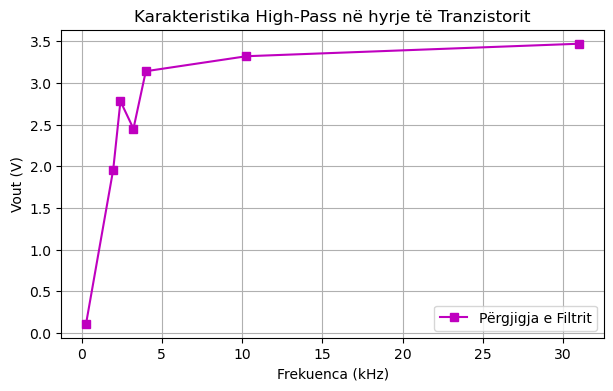

In [2]:
import matplotlib.pyplot as plt

data_hp = {
    'f (kHz)': [31.0, 10.27, 4.00, 2.42, 3.23, 1.97, 0.278],
    'Vout (V)': [3.47, 3.32, 3.14, 2.78, 2.45, 1.96, 0.11]
}
df_hp = pd.DataFrame(data_hp).sort_values('f (kHz)')

plt.figure(figsize=(7,4))
plt.plot(df_hp['f (kHz)'], df_hp['Vout (V)'], 'ms-', label='Përgjigja e Filtrit')
plt.title('Karakteristika High-Pass në hyrje të Tranzistorit')
plt.xlabel('Frekuenca (kHz)'); plt.ylabel('Vout (V)'); plt.grid(True); plt.legend()
plt.show()

In [4]:
# Llogaritja e rezistencës hyrëse dinamike (r_pi)
# Formula: r_pi = (26mV * Beta) / IC (mA)
thermal_voltage = 26 # mV në temperaturë dhome
r_pi = (thermal_voltage * beta) 

print(f"Rezistenca hyrëse dinamike (r_pi): {r_pi:.2f} Ohm")

Rezistenca hyrëse dinamike (r_pi): 5.64 Ohm


### Analiza e Rezistencës Hyrëse
Llogaritja e rezistencës hyrëse dinamike ($r_\pi$) është esenciale për të kuptuar ndërveprimin midis filtrit dhe tranzistorit. 
* Një $r_\pi$ e lartë do të thotë që tranzistori nuk e "shuan" sinjalin që vjen nga filtri.
* Kjo vlerë ndikon në përcaktimin e rezistencës ekuivalente që sheh kondensatori i filtrit High-Pass, duke diktuar frekuencën e saktë të prerjes së sistemit

### 3. Përfundime
1. **Regjimi i Punës:** Tensioni $V_{BE} = V_b - V_e = 0.743V$ vërteton se tranzistori është në regjimin **Aktiv**, pasi tejkalon barrierën prej 0.7V të silicit.
2. **Transferimi i Rrymës:** Verifikuam me saktësi pothuajse absolute ligjin e Kirhofit ($I_e \approx I_c + I_b$), ku diferenca midis vlerës së matur dhe asaj të llogaritur është vetëm 0.001 mA.
3. **Sjellja e Filtrit:** Filtri High-Pass lejon kalimin e sinjaleve me frekuencë të lartë drejt bazës së tranzistorit, duke bllokuar frekuencat e ulëta (nën 1 kHz), siç shihet nga rënia e tensionit $V_{out}$ në 0.11V.